In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
file_path = '/content/synthetic_mimic_ed_data.csv'
df = pd.read_csv(file_path)

In [13]:
df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])
df['los_hrs'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600
df.drop(columns=['intime', 'outtime'], inplace=True)


In [14]:
df['time_to_icu_hrs'] = df['time_to_icu_hrs'].fillna(9999)

In [15]:
y = df['acuity_mts_level'] - 1
X = df.drop(columns=['acuity_mts_level', 'subject_id', 'stay_id'])

In [16]:
STATIC_COLS = ['age', 'gender', 'race', 'icd_code']
TIME_SERIES_PROXY_COLS = [
    'hr_initial', 'rr_initial', 'sbp_min',
    'o2sat_min', 'temp_initial', 'los_hrs', 'time_to_icu_hrs'
]
TEXT_COLS = ['chief_complaint', 'pain']


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), TIME_SERIES_PROXY_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), STATIC_COLS),
    ],
    remainder='drop'
)


In [18]:
X_processed = preprocessor.fit_transform(X)


In [19]:
num_features_len = len(TIME_SERIES_PROXY_COLS)
static_features_len = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(STATIC_COLS).shape[0]


In [20]:
X_num_cat = pd.DataFrame(X_processed)
X_text = X['chief_complaint']


In [21]:
y_onehot = keras.utils.to_categorical(y, num_classes=5)


In [22]:
print(f"Total features (Num/Cat): {X_num_cat.shape[1]}")
print(f"Total samples: {X_num_cat.shape[0]}")

Total features (Num/Cat): 95
Total samples: 10000


In [23]:
X_train_num_cat, X_test_num_cat, \
X_train_text, X_test_text, \
y_train_onehot, y_test_onehot = train_test_split(
    X_num_cat, X_text, y_onehot,
    test_size=0.2, random_state=42, stratify=y
)


In [24]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_num_cat,
    np.argmax(y_train_onehot, axis=1)
)
y_train_smote_onehot = keras.utils.to_categorical(y_train_smote, 5)


In [25]:
TEXT_VECTOR_LENGTH = 100

def get_text_vector(n):
    return np.random.rand(n, TEXT_VECTOR_LENGTH).astype(np.float32)

X_train_text_vectors_smote = get_text_vector(len(X_train_smote))
X_test_text_vectors = get_text_vector(len(X_test_text))


In [26]:
static_input = Input(shape=(X_train_smote.shape[1],), name='static_time_input')
text_input = Input(shape=(TEXT_VECTOR_LENGTH,), name='text_input')

static_branch = Dense(128, activation='relu')(static_input)
static_branch = Dropout(0.3)(static_branch)
static_branch = Dense(64, activation='relu')(static_branch)

text_branch = Dense(64, activation='relu')(text_input)
text_branch = Dropout(0.3)(text_branch)

fused = Concatenate()([static_branch, text_branch])
output = Dense(5, activation='softmax')(fused)

model = Model([static_input, text_input], output)

In [27]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='roauc')]
)

In [28]:
X_train_static_final = X_train_smote.values.astype(np.float32)
X_test_static_final = X_test_num_cat.values.astype(np.float32)

y_test_targets_final = y_test_onehot.astype(np.float32)

history = model.fit(
    {'static_time_input': X_train_static_final,
     'text_input': X_train_text_vectors_smote},
    y_train_smote_onehot,
    epochs=10,
    batch_size=32,
    validation_data=(
        {'static_time_input': X_test_static_final,
         'text_input': X_test_text_vectors},
        y_test_targets_final
    ),
    verbose=1
)


Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6541 - loss: 0.7366 - roauc: 0.9161 - val_accuracy: 0.5795 - val_loss: 0.4757 - val_roauc: 0.9349
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8224 - loss: 0.2870 - roauc: 0.9832 - val_accuracy: 0.6455 - val_loss: 0.4447 - val_roauc: 0.9468
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8358 - loss: 0.2723 - roauc: 0.9851 - val_accuracy: 0.7175 - val_loss: 0.4200 - val_roauc: 0.9603
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8620 - loss: 0.2529 - roauc: 0.9882 - val_accuracy: 0.7455 - val_loss: 0.4092 - val_roauc: 0.9653
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.2455 - roauc: 0.9891 - val_accuracy: 0.8010 - val_loss: 0.3888 - val_roauc: 0.9736
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8835 - loss: 0.2279 - roauc: 0.9913 - val_accuracy: 0.8005 - val_loss: 0.4023 - val_roauc: 0.9736
Epoch 7/10
566/5

In [29]:
y_pred_proba = model.predict(
    {'static_time_input': X_test_static_final,
     'text_input': X_test_text_vectors}
)

y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = np.argmax(y_test_targets_final, axis=1)

print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=[
        'Level 1 (Critical)', 'Level 2', 'Level 3', 'Level 4', 'Level 5'
    ]
))

# AUPRC (Critical)
for i in [0, 1]:
    ap = average_precision_score(y_test_targets_final[:, i], y_pred_proba[:, i])
    print(f"AUPRC Level {i+1}: {ap:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                    precision    recall  f1-score   support

Level 1 (Critical)       0.89      0.73      0.80        11
           Level 2       0.97      0.99      0.98        99
           Level 3       1.00      1.00      1.00       697
           Level 4       0.76      0.81      0.79       905
           Level 5       0.26      0.21      0.23       288

          accuracy                           0.80      2000
         macro avg       0.78      0.75      0.76      2000
      weighted avg       0.78      0.80      0.79      2000

AUPRC Level 1: 0.8945
AUPRC Level 2: 0.9984


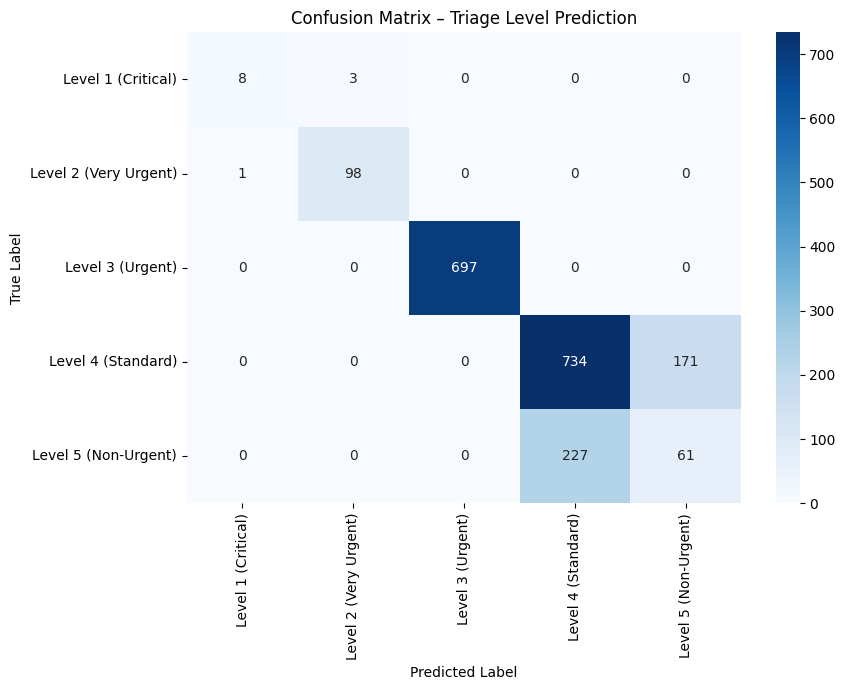

                       precision    recall  f1-score   support

   Level 1 (Critical)       0.89      0.73      0.80        11
Level 2 (Very Urgent)       0.97      0.99      0.98        99
     Level 3 (Urgent)       1.00      1.00      1.00       697
   Level 4 (Standard)       0.76      0.81      0.79       905
 Level 5 (Non-Urgent)       0.26      0.21      0.23       288

             accuracy                           0.80      2000
            macro avg       0.78      0.75      0.76      2000
         weighted avg       0.78      0.80      0.79      2000



In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert one-hot to class labels
y_true = np.argmax(y_test_targets_final, axis=1)
y_pred = np.argmax(y_pred_proba, axis=1)

target_names = [
    'Level 1 (Critical)',
    'Level 2 (Very Urgent)',
    'Level 3 (Urgent)',
    'Level 4 (Standard)',
    'Level 5 (Non-Urgent)'
]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix – Triage Level Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Optional: textual report
print(classification_report(y_true, y_pred, target_names=target_names))


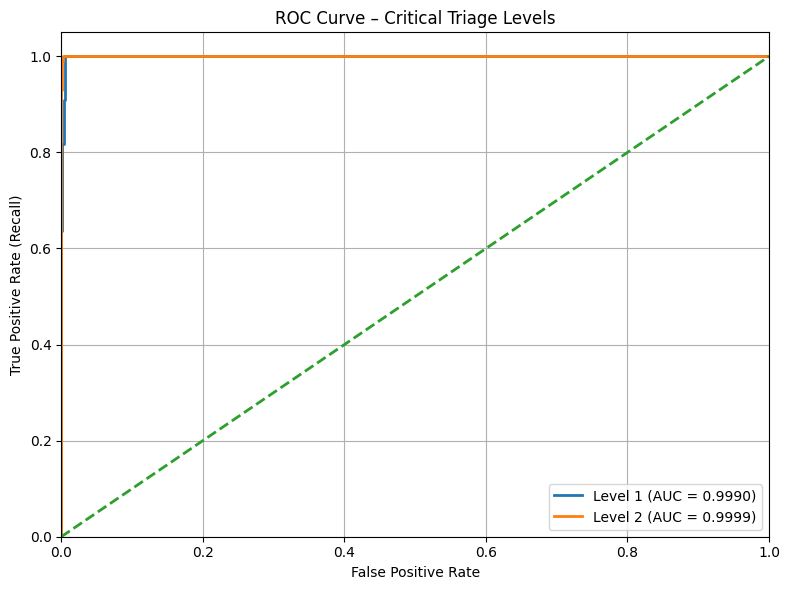

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))
lw = 2
critical_classes = [0, 1]

for i in critical_classes:
    fpr, tpr, _ = roc_curve(
        y_test_targets_final[:, i],
        y_pred_proba[:, i]
    )
    auc_score = roc_auc_score(
        y_test_targets_final[:, i],
        y_pred_proba[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        lw=lw,
        label=f'Level {i+1} (AUC = {auc_score:.4f})'
    )

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', lw=lw)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve – Critical Triage Levels')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Level 1 (Critical): AUPRC = 0.8945
Level 2 (Very Urgent): AUPRC = 0.9984

Macro-Averaged AUPRC (Level 1 & 2): 0.9464


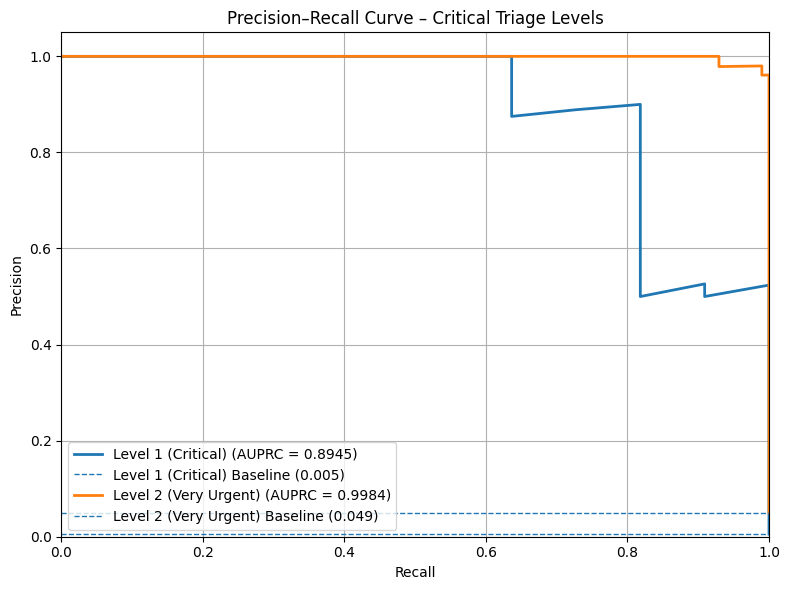

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

critical_classes = [0, 1]
labels = ['Level 1 (Critical)', 'Level 2 (Very Urgent)']

for i, label in zip(critical_classes, labels):
    precision, recall, _ = precision_recall_curve(
        y_test_targets_final[:, i],
        y_pred_proba[:, i]
    )
    ap = average_precision_score(
        y_test_targets_final[:, i],
        y_pred_proba[:, i]
    )

    # No-skill baseline = prevalence
    baseline = y_test_targets_final[:, i].mean()

    plt.plot(
        recall,
        precision,
        lw=2,
        label=f'{label} (AUPRC = {ap:.4f})'
    )
    plt.axhline(
        y=baseline,
        linestyle='--',
        lw=1,
        label=f'{label} Baseline ({baseline:.3f})'
    )

    print(f"{label}: AUPRC = {ap:.4f}")

# Macro AUPRC (Critical)
macro_auprc = (
    average_precision_score(y_test_targets_final[:, 0], y_pred_proba[:, 0]) +
    average_precision_score(y_test_targets_final[:, 1], y_pred_proba[:, 1])
) / 2

print(f"\nMacro-Averaged AUPRC (Level 1 & 2): {macro_auprc:.4f}")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve – Critical Triage Levels')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
!pip install shap captum

INFO: pip is looking at multiple versions of captum to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.9 MB/s eta 0:00:00


In [37]:
import shap
import numpy as np
import tensorflow as tf

# Wrapper: fixes text input while explaining static branch
class StaticOnlyModel(tf.keras.Model):
    def __init__(self, full_model, fixed_text_input):
        super().__init__()
        self.full_model = full_model
        self.fixed_text_input = fixed_text_input

    def call(self, static_input):
        batch_size = tf.shape(static_input)[0]
        repeated_text = tf.repeat(
            tf.expand_dims(self.fixed_text_input, axis=0),
            repeats=batch_size,
            axis=0
        )
        return self.full_model(
            {'static_time_input': static_input,
             'text_input': repeated_text}
        )


In [38]:
# Use mean text vector as neutral baseline
text_baseline = np.mean(X_train_text_vectors_smote, axis=0)

static_explainer_model = StaticOnlyModel(model, text_baseline)

# SHAP background (small subset for speed)
background = X_train_static_final[np.random.choice(
    X_train_static_final.shape[0], 100, replace=False
)]

explainer = shap.Explainer(static_explainer_model, background)


In [39]:
# Pick one test patient
patient_idx = 0
shap_values = explainer(X_test_static_final[patient_idx:patient_idx+1])


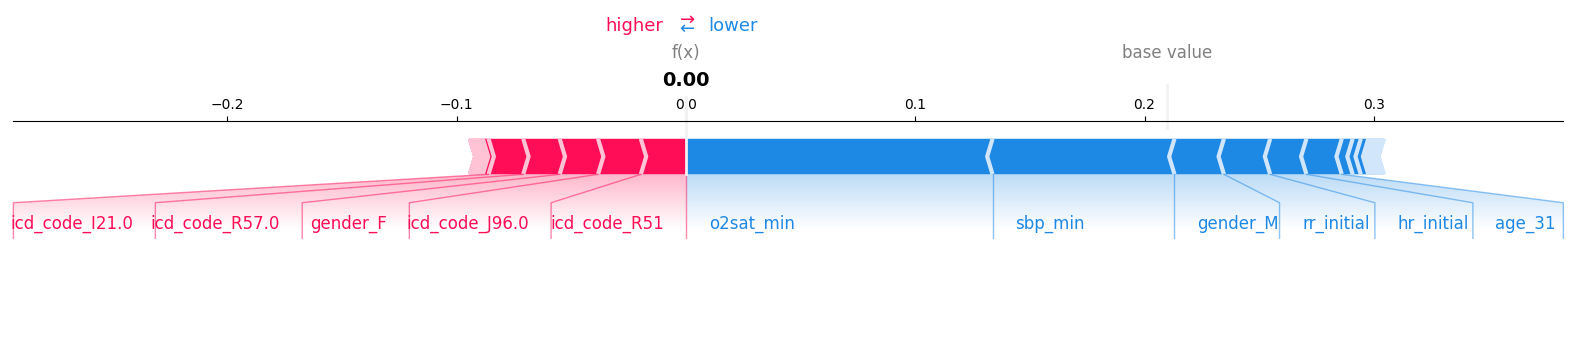

In [41]:
# For PermutationExplainer, use base_values instead of expected_value

shap.force_plot(
    shap_values.base_values[0][0],        # base value for class 0
    shap_values.values[0][:, 0],           # SHAP values for class 0
    feature_names=feature_names,
    matplotlib=True
)


In [46]:
class TextOnlyModel(tf.keras.Model):
    def __init__(self, full_model, fixed_static_input):
        super().__init__()
        self.full_model = full_model
        self.fixed_static_input = tf.convert_to_tensor(
            fixed_static_input, dtype=tf.float32
        )

    def call(self, text_input):
        batch_size = tf.shape(text_input)[0]
        repeated_static = tf.repeat(
            tf.expand_dims(self.fixed_static_input, axis=0),
            repeats=batch_size,
            axis=0
        )
        return self.full_model(
            {
                'static_time_input': repeated_static,
                'text_input': text_input
            }
        )


In [47]:
def integrated_gradients(
    model,
    input_tensor,
    baseline,
    target_class,
    steps=50
):
    """
    TensorFlow-native Integrated Gradients
    """
    input_tensor = tf.cast(input_tensor, tf.float32)
    baseline = tf.cast(baseline, tf.float32)

    interpolated_inputs = [
        baseline + (float(i) / steps) * (input_tensor - baseline)
        for i in range(steps + 1)
    ]

    interpolated_inputs = tf.concat(interpolated_inputs, axis=0)

    with tf.GradientTape() as tape:
        tape.watch(interpolated_inputs)
        preds = model(interpolated_inputs)
        preds = preds[:, target_class]

    grads = tape.gradient(preds, interpolated_inputs)
    avg_grads = tf.reduce_mean(grads, axis=0, keepdims=True)

    integrated_grads = (input_tensor - baseline) * avg_grads
    return integrated_grads


In [48]:
# Select patient
patient_idx = 0

# Prepare inputs
text_input = tf.convert_to_tensor(
    X_test_text_vectors[patient_idx:patient_idx+1],
    dtype=tf.float32
)

baseline_text = tf.zeros_like(text_input)

# Static baseline (mean vitals)
static_baseline = np.mean(X_train_static_final, axis=0)

# Build text-only explainer model
text_explainer_model = TextOnlyModel(model, static_baseline)

# Compute IG for Level 1 (Critical)
ig_attributions = integrated_gradients(
    model=text_explainer_model,
    input_tensor=text_input,
    baseline=baseline_text,
    target_class=0,
    steps=50
)


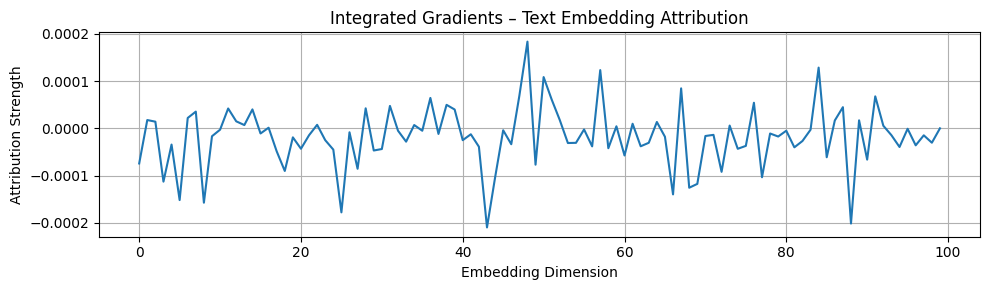

In [49]:
import matplotlib.pyplot as plt

attr = ig_attributions.numpy()[0]

plt.figure(figsize=(10, 3))
plt.plot(attr)
plt.title("Integrated Gradients – Text Embedding Attribution")
plt.xlabel("Embedding Dimension")
plt.ylabel("Attribution Strength")
plt.grid(True)
plt.tight_layout()
plt.show()
